In [9]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

all_data = pd.read_csv("C:\\Users\\ASUS\\Documents\\Prac\homework_1\\forest_dataset.csv")
all_data.head()

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values


clf = KNeighborsClassifier(n_neighbors=1, weights=None, metric="euclidean")
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
accuracy_score(test_labels, y_pred)

<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9340\3890579322.py:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  all_data = pd.read_csv("C:\\Users\\ASUS\\Documents\\Prac\homework_1\\forest_dataset.csv")


0.783

In [10]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)

clf_grid.fit(train_feature_matrix, train_labels)

print(f"Лучшие параметры: {clf_grid.best_params_}")
print(f"Лучшая кросс-валидационная точность: {clf_grid.best_score_:.3f}")

# Оценка на тестовой выборке
best_clf = clf_grid.best_estimator_
y_pred = best_clf.predict(test_feature_matrix)
test_accuracy = accuracy_score(test_labels, y_pred)
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")


Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Лучшая кросс-валидационная точность: 0.768
Точность на тестовой выборке: 0.784


In [11]:
optimal_clf = clf_grid.best_estimator_

optimal_clf.fit(train_feature_matrix, train_labels)

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

print(f"Форма массива вероятностей: {pred_prob.shape}")
print(f"Вероятности для первых 5 тестовых объектов:\n{pred_prob[:5]}")
print(f"Предсказанные классы: {optimal_clf.predict(test_feature_matrix)[:5]}")
print(f"Максимальные вероятности: {pred_prob.max(axis=1)[:5]}")

Форма массива вероятностей: (2000, 7)
Вероятности для первых 5 тестовых объектов:
[[0.         1.         0.         0.         0.         0.
  0.        ]
 [0.73117861 0.26882139 0.         0.         0.         0.
  0.        ]
 [0.27814042 0.72185958 0.         0.         0.         0.
  0.        ]
 [1.         0.         0.         0.         0.         0.
  0.        ]
 [0.         1.         0.         0.         0.         0.
  0.        ]]
Предсказанные классы: [2 1 2 1 2]
Максимальные вероятности: [1.         0.73117861 0.72185958 1.         1.        ]


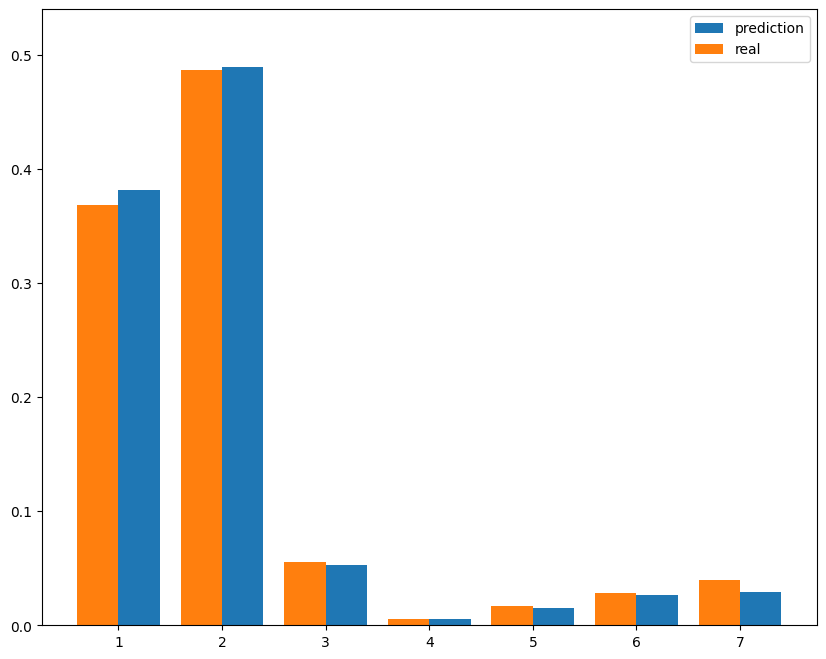

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()
